<a href="https://colab.research.google.com/github/zahrasyifaa/Text-Classification/blob/main/cleaning_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Library**

In [ ]:
pip install ftfy

In [ ]:
#nltk.download('punkt')

In [ ]:
#!pip show nltk

Name: nltk
Version: 3.9.1
Summary: Natural Language Toolkit
Home-page: https://www.nltk.org/
Author: NLTK Team
Author-email: nltk.team@gmail.com
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: click, joblib, regex, tqdm
Required-by: textblob


In [ ]:
!pip install nltk

In [ ]:
!pip install PySastrawi # Install PySastrawi

In [ ]:
!pip install tqdm #Instal Stemming

In [ ]:
pip install pandas openpyxl wordcloud matplotlib #Wordcloud

In [ ]:
!pip install wordcloud openpyxl

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import ftfy
from collections import Counter
from nltk.tokenize import word_tokenize #tokenisasi
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from Sastrawi.StopWordRemover.StopWordRemoverFactory import (StopWordRemoverFactory, StopWordRemover, ArrayDictionary) # stopword remover Indo
import ast
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory #stemming
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **Labeling Data & Membuang Baris Ambigu**

In [ ]:
# Load file
df = pd.read_excel('topic 2 teratas.xlsx', header=0)
df.columns = ['answer', 'kehamilan', 'menstruasi']

# Labeling
def assign_label(row):
    has_k = pd.notna(row['kehamilan'])
    has_m = pd.notna(row['menstruasi'])
    if has_k and has_m:
        return None   # buang baris ambigu
    elif has_k:
        return 0      # kehamilan = 0
    elif has_m:
        return 1      # menstruasi = 1
    return None

df['label'] = df.apply(assign_label, axis=1)

# Buang baris ambigu dan simpan
df_clean = df[df['label'].notna()].copy()
df_clean['label'] = df_clean['label'].astype(int)
df_output = df_clean[['answer', 'label']].reset_index(drop=True)

# Export
df_output.to_excel('data_labeled.xlsx', index=False)
print(df_output['label'].value_counts())

label
0    8915
1    8890
Name: count, dtype: int64


# **Data Preprocessing**

**Cleaning Teks**

In [ ]:
#CLEANING
df = pd.read_excel('data_labeled.xlsx')

# Hapus Encoding
def clean_encoding(teks):
    teks = ftfy.fix_text(str(teks))                       # Perbaiki mojibake (â€™ → ')
    teks = unicodedata.normalize('NFKD', teks)            # Normalisasi unicode
    teks = teks.encode('ascii', 'ignore').decode('ascii') # Hapus non-ASCII sisa
    return re.sub(r'\s+', ' ', teks).strip()

# Hapus Salam
_SALAM = (
    r"(?:Wa\s+alaikumsalam"
    r"|Wa+['\u2019`]?a*laiku(?:m|mu|ms|muss|msal|msall|m\s)s?a+l+[ae]?m*"
    r"|Waalaikum\s+salam)"
)
_WR_WB = r"(?:wrwb\.?|wr\.?\s*wb\.?|warohmatullohi\s+wabarokatuh)?"
_GELAR = r"(?:Ibu|Bapak|Pak|Bu|Mbak|Mas|Kak|Mba|Sdr\.?|Sdri\.?|Halo|Hai)?"
_NAMA  = r"(?:[A-Za-z][a-zA-Z0-9']*(?:\s+[A-Z][a-zA-Z0-9']*)*)?"

POLA_SALAM = re.compile(
    rf'^\s*{_SALAM}\s*{_WR_WB}\s*{_GELAR}\s*{_NAMA}\s*[,.\s]*',
    re.IGNORECASE
)
def hapus_salam(teks):
    teks = POLA_SALAM.sub('', teks)
    return re.sub(r'^[,.\s]+', '', teks).strip()

# HAPUS SAPAAN & NAMA
NAMA_P   = r'(?:[A-Z][a-zA-Z0-9-]*(?:\s+[A-Z][a-zA-Z0-9-]*){0,3}\s*)'
NAMA_NP  = r'(?:[A-Z][a-zA-Z0-9-]*\s*)'
NAMA_DOT = r'(?:[\w][\w.]*[\w]\s*)'
GELAR = r'(?:Ibu|Bapak|Pak|Bu|Mbak|Mas|Kak|Mba|Sdr\.?|Sdri\.?|Saudar[ai]|Bunda|Sis)\s+'
SAPAAN = r'(?:Hal+[lo]*r?|Ha(?:i+)|Hel+[lo]*|Hi+|Al+o+)'

def hapus_sapaan_dan_nama(teks):
    # Dear
    teks = re.sub(rf'^\s*[Dd]ear\s+{NAMA_P}[,.]?\s*', '', teks)
    teks = re.sub(rf'^\s*[Dd]ear\s*[,.]?\s*', '', teks)
    # Sapaan nempel (HaiBercak, HaloRia)
    teks = re.sub(rf'^\s*{SAPAAN}(?=[A-Z])', '', teks)
    # Sapaan + Gelar + Nama + koma  ← HARUS SEBELUM rule nempel
    teks = re.sub(rf'^\s*{SAPAAN}\s+{GELAR}{NAMA_P}[,.]\s*', '', teks, flags=re.IGNORECASE)
    teks = re.sub(rf'^\s*{SAPAAN}\s+{GELAR}{NAMA_P}(?=[A-Z])', '', teks) #BARUU
    # Sapaan + Gelar + Nama nempel ke konten (Hallo Ibu AriniSaya)
    teks = re.sub(rf'^\s*{SAPAAN}\s+{GELAR}([A-Z][a-z]+)(?=[A-Z])', '', teks)
    # Sapaan + Gelar + Nama tanpa koma
    teks = re.sub(rf'^\s*{SAPAAN}\s+{GELAR}{NAMA_NP}(?=[A-Z])', '', teks)
    # Sapaan + Gelar tanpa nama
    teks = re.sub(rf'^\s*{SAPAAN}\s+{GELAR}\s*[,.]?\s*', '', teks, flags=re.IGNORECASE)
    # Sapaan + Nama titik tengah + koma (Hai arkan.n.r,)
    teks = re.sub(rf'^\s*{SAPAAN}\s+{NAMA_DOT}[,.]\s*', '', teks, flags=re.IGNORECASE)
    # Sapaan + Nama + koma → hanya jika setelah koma huruf kecil
    teks = re.sub(rf'^\s*{SAPAAN}\s*[,.]?\s*{NAMA_P}[,.]\s*(?=[a-z])', '', teks, flags=re.IGNORECASE)
    # Sapaan + Nama 1 kata tanpa koma
    teks = re.sub(rf'^\s*{SAPAAN}\s+{NAMA_NP}(?=[A-Z])', '', teks)
    # Sapaan saja (Halo, / Alo! / Haiii / Halo,Saat)
    teks = re.sub(rf'^\s*{SAPAAN}[!]?\s*,?\s*', '', teks, flags=re.IGNORECASE)
    # Selamat pagi/siang/sore/malam
    teks = re.sub(rf'^\s*[Ss]elamat\s+(pagi|siang|sore|malam)\s+{NAMA_DOT}[,.]\s*', '', teks, flags=re.IGNORECASE)
    teks = re.sub(rf'^\s*[Ss]elamat\s+(pagi|siang|sore|malam)\s*[,.]?\s*{NAMA_P}[,.]\s*', '', teks, flags=re.IGNORECASE)
    teks = re.sub(r'^\s*[Ss]elamat\s+(pagi|siang|sore|malam)\s*[,.]?\s*', '', teks, flags=re.IGNORECASE)
    # Nama yang baik
    teks = re.sub(r'^\s*[A-Z]\w*\s+yang\s+baik\s*[,.]?\s*', '', teks, flags=re.IGNORECASE)
    # Sisa nama underscore
    teks = re.sub(r'^\s*[A-Z]+[_\-][A-Za-z]+\s*[,.]?\s*', '', teks)
    return re.sub(r'\s+', ' ', teks).strip()

# CASE FOLDING
def case_folding(teks):
    return teks.lower()

# CLEANING TEKS
def cleaning_teks(teks):
    teks = re.sub(r'<[^>]+>', ' ', teks)
    teks = re.sub(r'http\S+|www\S+|https\S+', '', teks)
    teks = re.sub(r'\d+', ' ', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = re.sub(r'_', ' ', teks)
    teks = re.sub(r'\b\w\b', ' ', teks)   # hapus kata 1 huruf
    return re.sub(r'\s+', ' ', teks).strip()

# TERAPKAN KE DATA
df['answer_clean'] = (df['answer']
    .apply(clean_encoding)
    .apply(hapus_salam)
    .apply(hapus_sapaan_dan_nama)
    .apply(case_folding)
    .apply(cleaning_teks)
)

# Simpan hasil
df.to_excel('data_cleaned.xlsx', index=False)

**Menghapus Noise**

In [ ]:
#NOISE
df = pd.read_excel('data_cleaned.xlsx')

# POLA PEMBUKA
POLA_PEMBUKA = re.compile(
    r'^\s*(?:saya\s+ingin\s+mengucapkan\s+)?'
    r'(terima\s*kasih|terimakasih)\s*'
    r'(banyak\s+|ya\s+|sudah\s+|telah\s+|untuk\s+)?'
    r'('
    # GRUP A: langsung kata kerja tanpa nama di tengah
    r'berta(?:n)?ya(\s+(di|ke|kepada|pada|melalui)\s+(?:website\s+|forum\s+)?(?:alodokter|alo\s+dokter)(?:\s+com)?)?'
    r'|menggunakan\s+(?:layanan|forum|jasa|aplikasi|fitur|jasa\s+konsultasi)\s*(?:\w+\s*){0,2}'
    r'|memberikan\s+pertanyaan(\s+(di|ke|kepada|pada)\s+(?:alodokter|alo\s+dokter)(?:\s+com)?)?'
    r'|pertanyaan\s+(anda|yang\s+(diberikan|diajukan))'
    r'|untuk\s+pertanyaan(\s+yang\s+(diberikan|diajukan))?'
    # GRUP B: nama opsional + atas pertanyaan
    r'|(?:[A-Za-z]+\s+){0,3}atas\s+pertanyaan\s*(nya|anda|(\s+yang\s+(diajukan|diberikan))?)?'
    r'(\s+(kepada|ke|untuk|pada|di)\s+(?:forum\s+|website\s+)?(?:alodokter|alo\s+dokter)(?:\s+com)?\s*)?'
    r')\s*'
    r'(?:(kepada|ke|di|pada|melalui)\s+(?:website\s+|forum\s+)?(?:alodokter|alo\s+dokter)(?:\s+com|\.\w+)?\s*)?'
    r'[,.]?\s*',
    re.IGNORECASE)

# POLA PERKENALAN DOKTER
POLA_PERKENALAN_DR = re.compile(
    r'(?:perkenalkan\s+)?'
    r'saya\s+'
    r'(?:dr\.?\s+|dokter\s+)'
    r'[a-z]+(?:\s+[a-z]+){0,5}'
    r'\s+(?:akan|ingin)\s+'
    r'(?:mencoba\s+)?'
    r'(?:membantu\s+|menjawab\s+|menjelaskan\s+){1,2}'  # wajib ada
    r'(?:pertanyaan\w*|permasalahan|keluhan)?\s*'
    r'(?:anda\s*)?'
    r'(?:(?:di|pada|kepada|ke)\s+\w+(?:\s+com)?\s*)?'
    r'[,.]?\s*',
    re.IGNORECASE)

# POLA PENUTUP
POLA_PENUTUP = re.compile(
    r'\s*[,.]?\s*('
    r'demikian\s+(penjelasan|informasi)\s+yang\s+dapat\s+kami'
    r'|demikian\s+(penjelasan|informasi)\s+dari\s+kami'
    r'|demikian\s+sekilas\s+info'
    r'|demikian\s+semoga'
    r'|penjelasan\s+yang\s+dapat\s+kami\s+sampaikan'
    r'|informasi\s+yang\s+dapat\s+kami\s+sampaikan'
    r'|semoga\s+(informasi\s+ini\s+)?(bermanfaat|membantu|bermafaat|bemanfaat|bermanfaa)'
    r'|semoga\s+(lekas|cepat)\s+sembuh'
    r'|semoga\s+(anda\s+)?sehat\s+selalu'
    r'|salam\s+(sehat|dr|,)'
    r'|salam\s*,\s*dr'
    r'|bila\s+ada\s+pertanyaan\s+lebih\s+lanjut'
    r'|jika\s+ada\s+pertanyaan\s+(lanjutan|lebih\s+lanjut)'
    r'|hormat\s+kami'
    r')',
    re.IGNORECASE)

# FUNGSI HAPUS NOISE
def hapus_noise(teks):
    if not isinstance(teks, str):
        return ''

    teks = re.sub(r'[.]{2,}', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()

    # Baris seluruhnya noise
    pola_noise_penuh = [
        r'^pertanyaan\s*(anda|ini|kamu|nya)?\s*(sudah|telah)\s*(di\s*jawab|dijawab|terjawab|dibalas)',
        r'^pertanyaannya?\s*(sudah\s*(di\s*)?jawab)',
        r'^(sudah|telah)\s*(di\s*jawab|dijawab|terjawab)',
        r'^dijawab\s+ya\s+(pada|di|dalam)',
        r'^jawaban\s*(anda|kamu)?\s*sudah\s*dijawab',
        r'^silakan\s*(klik|cek|buka|lihat)',
        r'^salam\s+pertanyaan',]

    for pola in pola_noise_penuh:
        if re.match(pola, teks.strip(), re.IGNORECASE):
            return ''

    # Hapus baris hanya nama dokter
    teks = re.sub(r'^\s*dr\.?\s+\w+(\s+\w+)?\s*$', '', teks, flags=re.IGNORECASE)

    # Hapus pembuka terima kasih
    m = POLA_PEMBUKA.match(teks)
    if m:
        teks = teks[m.end():].strip()

    # Sisa suffix setelah match pembuka
    teks = re.sub(
        r'^n?(nya|ya)\s+(di|ke|kepada|pada|forum)\s+(?:\w+\s+)?(?:alodokter|alo\s+dokter)(?:\s+com)?\s*[,.]?\s*',
        '', teks, flags=re.IGNORECASE)

    # Sisa "yang diajukan/diberikan" yang mungkin tersisa
    teks = re.sub(r'^yang\s+(diajukan|diberikan)\s*[,.]?\s*', '', teks, flags=re.IGNORECASE)

    # Hapus perkenalan dokter
    teks = re.sub(r'^\s*' + POLA_PERKENALAN_DR.pattern, '', teks, flags=re.IGNORECASE)

    # Sisa kata pendek
    teks = re.sub(r'^\s*(anda|di|pada|kepada|alodokter|com)\s*[,.]?\s*', '', teks, flags=re.IGNORECASE)

    # Semoga jawaban ini
    teks = re.sub(
        r'^\s*semoga\s+(jawaban\s+ini\s+)?(dapat\s+)?(membantu|bermanfaat)\s*(anda\s*)?\s*[,.]?\s*',
        '', teks, flags=re.IGNORECASE)

    # Penutup di akhir
    m = POLA_PENUTUP.search(teks)
    if m:
        teks = teks[:m.start()].strip()

    # Sisa nama dokter di akhir
    teks = re.sub(
        r'\s*[,.]?\s*dr\.?\s+[a-z]+(\s+[a-z]+){0,3}\s*$',
        '', teks, flags=re.IGNORECASE)

    return re.sub(r'\s+', ' ', teks).strip()

# TERAPKAN KE DATA
sebelum = len(df)

# Hapus noise
df['answer_noise'] = df['answer_clean'].apply(hapus_noise)
df = df[df['answer_noise'].fillna('').str.strip() != '']
df = df[df['answer_noise'].str.split().str.len() >= 3]

sebelum_dup = len(df)

# Hapus duplikat konflik (teks sama, label beda)
dup_semua    = df[df.duplicated(subset='answer_noise', keep=False)]
dup_konflik  = dup_semua.groupby('answer_noise')['label'].nunique()
teks_konflik = dup_konflik[dup_konflik > 1].index

print(f"  Duplikat konflik ditemukan: {len(teks_konflik)} teks")
if len(teks_konflik) > 0:
    for teks in teks_konflik:
        grp = df[df['answer_noise'] == teks][['answer_noise', 'label']]
        print(f"    label={grp['label'].tolist()} | {repr(teks[:80])}")

df = df[~df['answer_noise'].isin(teks_konflik)]

# Hapus duplikat sama label
sebelum_same_dup = len(df)
df = df.drop_duplicates(subset='answer_noise', keep='first')
df = df.reset_index(drop=True)

df.to_excel('data_noise_duplicate.xlsx', index=False)

print(f"\n{'='*45}")
print(f"  Data awal          : {sebelum} baris")
print(f"  Noise dihapus      : {sebelum - sebelum_dup} baris")
print(f"  Duplikat konflik hapus : {len(teks_konflik) * 2} baris")
print(f"  Duplikat sama label    : {sebelum_same_dup - len(df)} baris")
print(f"  Total duplikat dihapus     : {sebelum_dup - len(df)} baris")
print(f"  Data akhir         : {len(df)} baris")
print(f"\n  Distribusi label:")
print(df['label'].value_counts().to_string())
print(f"  Balance label      : {df['label'].value_counts().min()/df['label'].value_counts().max()*100:.1f}%")

  Duplikat konflik ditemukan: 4 teks
    label=[1, 0] | 'beberapa kondisi flek coklat juga terjadi lantaran dalam tubuh anda sedang terja'
    label=[1, 0] | 'perdarahan yang terjadi diantara diluar siklus menstruasi dikenal sebagai metror'
    label=[1, 0, 1, 0] | 'terlambat datang bulan biasanya memang adalah salah satu tanda utama kehamilan d'
    label=[0, 1] | 'terlambat haid tidak selalu disebabkan oleh kehamilan karena siklus haid dipenga'

  Data awal          : 17805 baris
  Noise dihapus      : 44 baris
  Duplikat konflik hapus : 8 baris
  Duplikat sama label    : 41 baris
  Total duplikat dihapus     : 51 baris
  Data akhir         : 17710 baris

  Distribusi label:
label
0    8870
1    8840
  Balance label      : 99.7%


# **NORMALISASI**

In [ ]:
df = pd.read_excel('data_noise_duplicate.xlsx')

TYPO_MAP = {
    'pemeriksaaan': 'pemeriksaan', 'keadaaan': 'keadaan',
    'perkiraaan': 'perkiraan',     'saaat': 'saat',
    'ganggguan': 'gangguan',       'bermanfaaat': 'bermanfaat',
    'kemungkinannnya': 'kemungkinannya', 'lainnnya': 'lainnya',
    'pertanyaaan': 'pertanyaan',   'dilakukannnya': 'dilakukannya',
    'penggunaaan': 'penggunaan',   'pengggunaan': 'penggunaan',
    'perbedaaan': 'perbedaan',     'pungggung': 'punggung',
    'dysmenorrrhea': 'dysmenorrhea', 'mingggu': 'minggu',
    'menorrrhagia': 'menorrhagia', 'sehinggga': 'sehingga',
    'ganggguan': 'gangguan',
}

KAMUS_NORMALISASI = {
    # frasa dulu (multi-kata)
    'datang bulan'     : 'menstruasi',
    'telat bulan'      : 'terlambat menstruasi',
    'terlambat bulan'  : 'terlambat menstruasi',
    'terlambat haid'   : 'terlambat menstruasi',
    'telat haid'       : 'terlambat menstruasi',
    'darah haid'       : 'darah menstruasi',
    'siklus haid'      : 'siklus menstruasi',
    'nyeri haid'       : 'nyeri menstruasi',
    'sakit haid'       : 'nyeri menstruasi',
    'hamil muda'       : 'trimester pertama',
    'berbadan dua'     : 'hamil',
    'positif hamil'    : 'hamil',
    'morning sickness' : 'mual kehamilan',
    'kb suntik'        : 'kontrasepsi suntik',
    'kb pil'           : 'kontrasepsi pil',
    'kb spiral'        : 'kontrasepsi iud',
    'test pack'        : 'tes kehamilan',
    # kata tunggal
    'haid'             : 'menstruasi',
    'mens'             : 'menstruasi',
    'kb'               : 'kontrasepsi',
    'spiral'           : 'iud',
    'usg'              : 'ultrasonografi',
    'testpack'         : 'tes kehamilan',
    'flek'             : 'bercak darah',
    'spotting'         : 'bercak darah',
    'yg'               : 'yang',
    'dgn'              : 'dengan',
    'dg'               : 'dengan',
    'krn'              : 'karena',
    'karna'            : 'karena',
    'utk'              : 'untuk',
    'sdh'              : 'sudah',
    'udah'             : 'sudah',
    'udh'              : 'sudah',
    'gak'              : 'tidak',
    'ga'               : 'tidak',
    'nggak'            : 'tidak',
    'ngga'             : 'tidak',
    'enggak'           : 'tidak',
    'tdk'              : 'tidak',
    'bgt'              : 'sangat',
    'banget'           : 'sangat',
    'aja'              : 'saja',
    'doang'            : 'saja',
    'emg'              : 'memang',
    'emang'            : 'memang',
    'gimana'           : 'bagaimana',
    'gmn'              : 'bagaimana',
    'kayak'            : 'seperti',
    'kyk'              : 'seperti',
    'buat'             : 'untuk',
    'telat'            : 'terlambat',
    'pd'               : 'pada',
    'tp'               : 'tapi',
    'tgl'              : 'tanggal',
    'dll'              : 'dan lain-lain',
    'dsb'              : 'dan sebagainya',
    'tsb'              : 'tersebut',
}

# Pisahkan frasa dan kata tunggal
_FRASA   = {k: v for k, v in KAMUS_NORMALISASI.items() if ' ' in k}
_TUNGGAL = {k: v for k, v in KAMUS_NORMALISASI.items() if ' ' not in k}

# Fungsi normalisasi
def normalisasi_kata(teks: str) -> str:
    if not isinstance(teks, str):
        return teks

    # 1. Bersihkan HTML (sisa tag dari scraping)
    for token in ('u lt', 'u gt', 'lt', 'gt', 'ext', 'style', 'align'):
        teks = re.sub(rf'\b{re.escape(token)}\b', '', teks)

    # 2. Koreksi typo duplikasi huruf
    for salah, benar in TYPO_MAP.items():
        teks = re.sub(rf'\b{re.escape(salah)}\b', benar, teks, flags=re.IGNORECASE)

    # 3. Normalisasi frasa (multi-kata) dulu
    for frasa, ganti in _FRASA.items():
        teks = re.sub(rf'\b{re.escape(frasa)}\b', ganti, teks, flags=re.IGNORECASE)

    # 4. Normalisasi kata tunggal — \b agar "buat" ≠ "membuat"
    for kata, ganti in _TUNGGAL.items():
        teks = re.sub(rf'\b{re.escape(kata)}\b', ganti, teks, flags=re.IGNORECASE)

    # 5. Bersihkan spasi berlebih
    return re.sub(r'\s+', ' ', teks).strip()


df = pd.read_excel('data_noise_duplicate.xlsx')

# Pastikan kolom
print(f"Kolom tersedia : {df.columns.tolist()}")
print(f"Total data     : {len(df)} baris\n")

# Normalisasi
df['answer_normalisasi'] = df['answer_noise'].apply(normalisasi_kata)

# Verifikasi perubahan
changed = (df['answer_noise'] != df['answer_normalisasi']).sum()
print(f"Baris berubah  : {changed} / {len(df)} ({changed/len(df)*100:.1f}%)")
print(f"Tidak berubah  : {len(df) - changed} baris\n")

# Contoh perubahan
print("── Contoh perubahan ──")
for _, row in df[df['answer_noise'] != df['answer_normalisasi']].head(3).iterrows():
    print(f"  SEBELUM: {row['answer_noise'][:120]}")
    print(f"  SESUDAH: {row['answer_normalisasi'][:120]}")
    print()

# Simpan
df.to_excel('data_normalisasi.xlsx', index=False)
print(f"Tersimpan: data_normalisasi.xlsx")
print(f"Distribusi label:\n{df['label'].value_counts().to_string()}")

Kolom tersedia : ['answer', 'label', 'answer_clean', 'answer_noise']
Total data     : 17710 baris

Baris berubah  : 14032 / 17710 (79.2%)
Tidak berubah  : 3678 baris

── Contoh perubahan ──
  SEBELUM: menstruasi yang normal berlangsung setiap hari sekali dan setiap siklusnya berlangsung selama hari menstruasi yang terja
  SESUDAH: menstruasi yang normal berlangsung setiap hari sekali dan setiap siklusnya berlangsung selama hari menstruasi yang terja

  SEBELUM: haid lebih dari bulan dan tidak berhenti yang anda alami kemungkinan merupakan menorrhagia mennorhagia adalah keadaan di
  SESUDAH: menstruasi lebih dari bulan dan tidak berhenti yang anda alami kemungkinan merupakan menorrhagia mennorhagia adalah kead

  SEBELUM: menstruasi yang normal berlangsung selama hari setiap hari sekali menstruasi yang terlambat dapat disebabkan oleh ketida
  SESUDAH: menstruasi yang normal berlangsung selama hari setiap hari sekali menstruasi yang terlambat dapat disebabkan oleh ketida

Tersimpan: data

# **TOKENISASI**

In [ ]:
# LOAD DATA
df = pd.read_excel('data_normalisasi.xlsx')
KOLOM = 'answer_normalisasi'

# FUNGSI TOKENISASI
def tokenisasi(teks):
    if not isinstance(teks, str) or teks.strip() == '':
        return []
    return word_tokenize(teks)

# TERAPKAN KE DATA
df['tokens'] = df[KOLOM].apply(tokenisasi)

# VERIFIKASI HASIL
print(f"Total data    : {len(df)} baris")
print(f"Kolom baru    : 'tokens'")
print(f"\n--- Contoh hasil (3 baris pertama) ---")
for i in range(3):
    teks   = df[KOLOM].iloc[i]
    tokens = df['tokens'].iloc[i]
    print(f"\nRow {i}:")
    print(f"  Teks   : {teks[:100]}")
    print(f"  Tokens : {tokens[:10]}...")
    print(f"  Jumlah : {len(tokens)} token")

# Statistik jumlah token
print(f"\n--- Statistik jumlah token ---")
df['jumlah_token'] = df['tokens'].apply(len)
print(f"  Rata-rata : {df['jumlah_token'].mean():.0f} token")
print(f"  Minimum   : {df['jumlah_token'].min()} token")
print(f"  Maximum   : {df['jumlah_token'].max()} token")
print(f"  Median    : {df['jumlah_token'].median():.0f} token")

# SIMPAN HASIL
df.to_excel('data_tokenisasi.xlsx', index=False)
print(f"\nHasil disimpan ke: data_tokenisasi.xlsx")

Total data    : 17710 baris
Kolom baru    : 'tokens'

--- Contoh hasil (3 baris pertama) ---

Row 0:
  Teks   : menstruasi yang normal berlangsung setiap hari sekali dan setiap siklusnya berlangsung selama hari m
  Tokens : ['menstruasi', 'yang', 'normal', 'berlangsung', 'setiap', 'hari', 'sekali', 'dan', 'setiap', 'siklusnya']...
  Jumlah : 122 token

Row 1:
  Teks   : menstruasi lebih dari bulan dan tidak berhenti yang anda alami kemungkinan merupakan menorrhagia men
  Tokens : ['menstruasi', 'lebih', 'dari', 'bulan', 'dan', 'tidak', 'berhenti', 'yang', 'anda', 'alami']...
  Jumlah : 149 token

Row 2:
  Teks   : menstruasi yang normal berlangsung selama hari setiap hari sekali menstruasi yang terlambat dapat di
  Tokens : ['menstruasi', 'yang', 'normal', 'berlangsung', 'selama', 'hari', 'setiap', 'hari', 'sekali', 'menstruasi']...
  Jumlah : 119 token

--- Statistik jumlah token ---
  Rata-rata : 189 token
  Minimum   : 3 token
  Maximum   : 803 token
  Median    : 174 token

Hasil d

# **STOPWORD**

In [ ]:
# LOAD DATA
df = pd.read_excel('data_tokenisasi.xlsx')

# STOPWORD KUSTOM
STOPWORD_KUSTOM = [
    # Kelompok 1: Sisa template Alodokter
    # (seharusnya sudah dihapus di noise, ini sebagai jaring pengaman)
    'alodokter', 'dokter', 'dr', 'com', 'diajukan',
    'semoga', 'bermanfaat', 'membantu',
    'terimakasih', 'terima', 'kasih',
    'artikel', 'baca', 'informasi',
    'salam', 'gmail',

    # Kelompok 2: Sisa sapaan yang lolos dari hapus_sapaan
    'hai', 'halo', 'hallo', 'hello', 'hi', 'alo',
    'dear', 'selamat',

    # Kelompok 3: Kata umum medis — tidak diskriminatif
    # Muncul hampir sama banyak di label kehamilan & menstruasi
    'pemeriksaan', 'kondisi', 'mengalami',
    'gejala', 'menyebabkan', 'perubahan',
    'lakukan', 'konsultasi', 'berkonsultasi',
    'spesialis', 'memeriksakan',
    'usg',          # sudah dinormalisasi ke "ultrasonografi" di tahap normalisasi

    # Kelompok 4: Kata umum non-informatif
    'dimana', 'waktu', 'memiliki',
    'bisa',
]

# BUAT STOPWORD REMOVER, Gabungkan stopword Sastrawi + kustom
factory          = StopWordRemoverFactory()
stopwords_sastrawi = factory.get_stop_words()

# Gabungkan & hapus duplikat
all_stopwords = list(set(stopwords_sastrawi + STOPWORD_KUSTOM))

dictionary = ArrayDictionary(all_stopwords)
remover    = StopWordRemover(dictionary)

print(f"Total stopword Sastrawi : {len(stopwords_sastrawi)}")
print(f"Total stopword kustom   : {len(STOPWORD_KUSTOM)}")
print(f"Total stopword gabungan : {len(all_stopwords)}")

# FUNGSI STOPWORD REMOVAL
def hapus_stopword(tokens):
    if not isinstance(tokens, list):
        return []
    # Gabung token → hapus stopword → pecah kembali
    teks        = ' '.join(tokens)
    teks_bersih = remover.remove(teks)
    return teks_bersih.split()

# TERAPKAN KE DATA
print("\nMenghapus stopword...")

# Konversi kolom tokens dari string ke list
import ast
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

df['tokens_clean'] = df['tokens'].apply(hapus_stopword)


# VERIFIKASI HASIL
df['jumlah_sebelum'] = df['tokens'].apply(len)
df['jumlah_sesudah'] = df['tokens_clean'].apply(len)
df['kata_dihapus']   = df['jumlah_sebelum'] - df['jumlah_sesudah']

print(f"\n--- Statistik ---")
print(f"Rata-rata token sebelum : {df['jumlah_sebelum'].mean():.0f}")
print(f"Rata-rata token sesudah : {df['jumlah_sesudah'].mean():.0f}")
print(f"Rata-rata kata dihapus  : {df['kata_dihapus'].mean():.0f}")

print(f"\n--- Contoh hasil (3 baris) ---")
for i in range(3):
    print(f"\nRow {i} | label={df['label'].iloc[i]}")
    print(f"  Sebelum ({df['jumlah_sebelum'].iloc[i]} token): {df['tokens'].iloc[i][:8]}")
    print(f"  Sesudah ({df['jumlah_sesudah'].iloc[i]} token): {df['tokens_clean'].iloc[i][:8]}")

# Hapus baris yang tokennya < 3 setelah stopword
sebelum = len(df)
df = df[df['tokens_clean'].apply(len) >= 3]
df = df.reset_index(drop=True)
print(f"\nBaris dihapus (< 3 token): {sebelum - len(df)}")

# SIMPAN HASIL
df.to_excel('data_stopword.xlsx', index=False)
print(f"\nHasil disimpan ke: data_stopword.xlsx")
print(f"Total data        : {len(df)} baris")
print(f"Distribusi label  :\n{df['label'].value_counts().to_string()}")

Total stopword Sastrawi : 809
Total stopword kustom   : 40
Total stopword gabungan : 843

Menghapus stopword...

--- Statistik ---
Rata-rata token sebelum : 189
Rata-rata token sesudah : 88
Rata-rata kata dihapus  : 101

--- Contoh hasil (3 baris) ---

Row 0 | label=1
  Sebelum (122 token): ['menstruasi', 'yang', 'normal', 'berlangsung', 'setiap', 'hari', 'sekali', 'dan']
  Sesudah (65 token): ['menstruasi', 'normal', 'siklusnya', 'menstruasi', 'oligomenorrhea', 'oligomenorrhea', 'disebabkan', 'ketidakseimbangan']

Row 1 | label=1
  Sebelum (149 token): ['menstruasi', 'lebih', 'dari', 'bulan', 'dan', 'tidak', 'berhenti', 'yang']
  Sesudah (60 token): ['menstruasi', 'berhenti', 'alami', 'menorrhagia', 'mennorhagia', 'diamana', 'menstruasi', 'disertai']

Row 2 | label=1
  Sebelum (119 token): ['menstruasi', 'yang', 'normal', 'berlangsung', 'selama', 'hari', 'setiap', 'hari']
  Sesudah (61 token): ['menstruasi', 'normal', 'menstruasi', 'terlambat', 'disebabkan', 'ketidakseimbangan', 'horm

# **STEMMING**

In [ ]:
# LOAD DATA
df = pd.read_excel('data_stopword.xlsx')

# Konversi kolom tokens_clean dari string ke list jika perlu
if isinstance(df['tokens_clean'].iloc[0], str):
    df['tokens_clean'] = df['tokens_clean'].apply(ast.literal_eval)

print(f"Total data : {len(df)} baris")
print(f"Kolom      : {df.columns.tolist()}\n")

# BUAT STEMMER
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# EXCEPTION LIST, Kata medis yang TIDAK boleh di-stem karena berubah makna
EXCEPTION_STEM = {
    # Kata medis yang berubah makna setelah stem
    'keputihan',        # → putih  (salah)
    'persalinan',       # → salin  (salah)
    'perkembangan',     # → kembang (salah)
    'berlangsung',      # → langsung (agak bergeser)

    # Kata serapan — sudah bentuk dasar
    'menstruasi',
    'kontrasepsi',
    'ultrasonografi',
    'trimester',
    'ovulasi',
    'fertilisasi',
    'implantasi',
    'plasenta',
    'embrio',
    'progesteron',
    'estrogen',
    'hemoglobin',
}

print(f"Total exception list : {len(EXCEPTION_STEM)} kata\n")

# FUNGSI STEMMING DENGAN EXCEPTION
def stemming(tokens):
    if not isinstance(tokens, list):
        return []
    hasil = []
    for token in tokens:
        if token in EXCEPTION_STEM:
            hasil.append(token)        # ← jangan di-stem
        else:
            hasil.append(stemmer.stem(token))  # ← stem seperti biasa
    return hasil

# TERAPKAN KE DATA
print("Melakukan stemming... (harap tunggu ~5-10 menit)")

try:
    from tqdm import tqdm
    tqdm.pandas()
    df['tokens_stem'] = df['tokens_clean'].progress_apply(stemming)
except ImportError:
    print("tqdm tidak tersedia, running tanpa progress bar...")
    df['tokens_stem'] = df['tokens_clean'].apply(stemming)

print("Stemming selesai!\n")

# VERIFIKASI — cek exception list bekerja
print("--- Verifikasi exception list ---")
contoh_exception = ['keputihan', 'persalinan', 'menstruasi', 'kontrasepsi']
for kata in contoh_exception:
    stem_normal    = stemmer.stem(kata)
    stem_exception = kata  # karena ada di exception
    print(f"  {kata:<20} stem normal={stem_normal:<15} exception={stem_exception} ✅")

# STATISTIK
df['jumlah_sebelum'] = df['tokens_clean'].apply(len)
df['jumlah_sesudah'] = df['tokens_stem'].apply(len)

vocab_sebelum = set(t for tokens in df['tokens_clean'] for t in tokens)
vocab_sesudah = set(t for tokens in df['tokens_stem'] for t in tokens)

print(f"\n--- Statistik ---")
print(f"Rata-rata token sebelum  : {df['jumlah_sebelum'].mean():.0f}")
print(f"Rata-rata token sesudah  : {df['jumlah_sesudah'].mean():.0f}")
print(f"Vocabulary sebelum       : {len(vocab_sebelum)} kata unik")
print(f"Vocabulary sesudah       : {len(vocab_sesudah)} kata unik")
print(f"Reduksi vocabulary       : {len(vocab_sebelum)-len(vocab_sesudah)} kata ({(len(vocab_sebelum)-len(vocab_sesudah))/len(vocab_sebelum)*100:.1f}%)")

# CONTOH HASIL
print(f"\n--- Contoh hasil (5 baris) ---")
for i in range(5):
    print(f"\nRow {i} | label={df['label'].iloc[i]}")
    print(f"  Sebelum : {df['tokens_clean'].iloc[i][:8]}")
    print(f"  Sesudah : {df['tokens_stem'].iloc[i][:8]}")

# HAPUS BARIS < 3 TOKEN SETELAH STEMMING
sebelum = len(df)
df = df[df['tokens_stem'].apply(len) >= 3]
df = df.reset_index(drop=True)
print(f"\nBaris dihapus (< 3 token): {sebelum - len(df)}")

# SIMPAN HASIL
df.to_excel('data_stemming.xlsx', index=False)

print(f"\nSelesai!")
print(f"  Tersimpan ke    : data_stemming.xlsx")
print(f"  Total data      : {len(df)} baris")
print(f"  Distribusi label:\n{df['label'].value_counts().to_string()}")
print(f"  Balance label   : {df['label'].value_counts().min()/df['label'].value_counts().max()*100:.1f}%")

Total data : 17703 baris
Kolom      : ['answer', 'label', 'answer_clean', 'answer_noise', 'answer_normalisasi', 'tokens', 'jumlah_token', 'tokens_clean', 'jumlah_sebelum', 'jumlah_sesudah', 'kata_dihapus']

Total exception list : 16 kata

Melakukan stemming... (harap tunggu ~5-10 menit)


100%|██████████| 17703/17703 [00:17<00:00, 988.65it/s] 


Stemming selesai!

--- Verifikasi exception list ---
  keputihan            stem normal=putih           exception=keputihan ✅
  persalinan           stem normal=salin           exception=persalinan ✅
  menstruasi           stem normal=menstruasi      exception=menstruasi ✅
  kontrasepsi          stem normal=kontrasepsi     exception=kontrasepsi ✅

--- Statistik ---
Rata-rata token sebelum  : 88
Rata-rata token sesudah  : 88
Vocabulary sebelum       : 22004 kata unik
Vocabulary sesudah       : 16022 kata unik
Reduksi vocabulary       : 5982 kata (27.2%)

--- Contoh hasil (5 baris) ---

Row 0 | label=1
  Sebelum : ['menstruasi', 'normal', 'siklusnya', 'menstruasi', 'oligomenorrhea', 'oligomenorrhea', 'disebabkan', 'ketidakseimbangan']
  Sesudah : ['menstruasi', 'normal', 'siklus', 'menstruasi', 'oligomenorrhea', 'oligomenorrhea', 'sebab', 'ketidakseimbangan']

Row 1 | label=1
  Sebelum : ['menstruasi', 'berhenti', 'alami', 'menorrhagia', 'mennorhagia', 'diamana', 'menstruasi', 'disertai'

# **WORDCLOUD**

In [ ]:
!pip install wordcloud matplotlib openpyxl -q

Total data     : 17703 baris
Kehamilan (0)  : 8865 baris
Menstruasi (1) : 8838 baris

SEMUA DATA


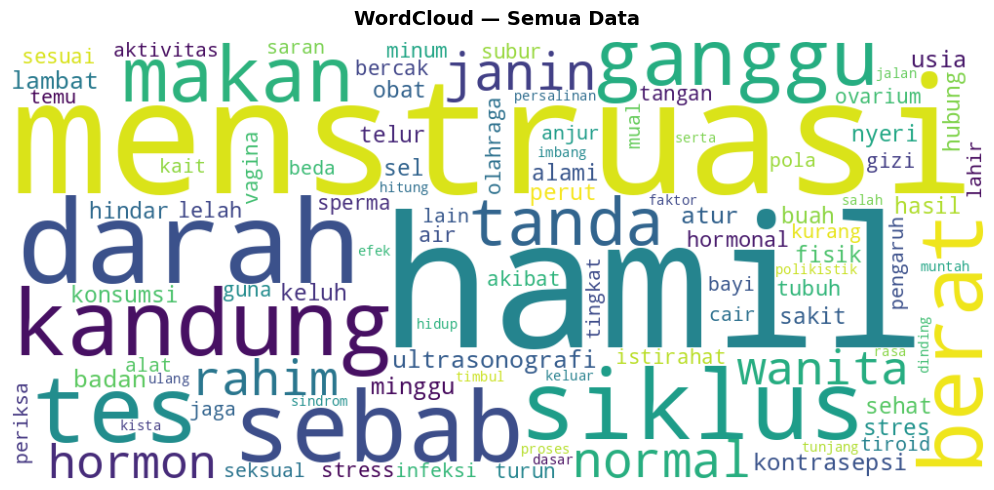

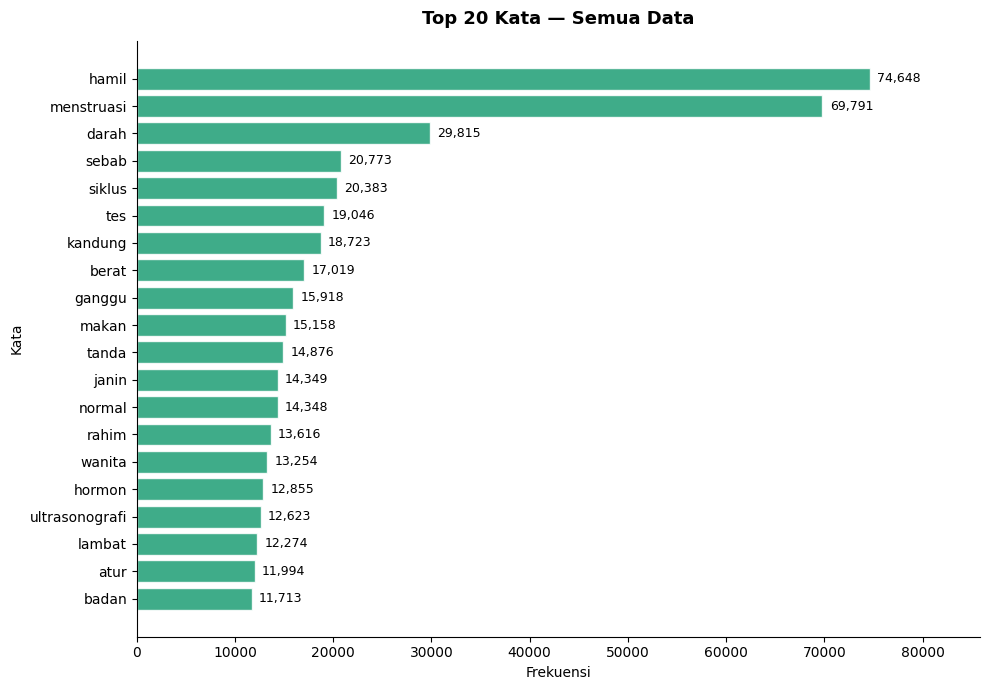

KEHAMILAN (Label 0)


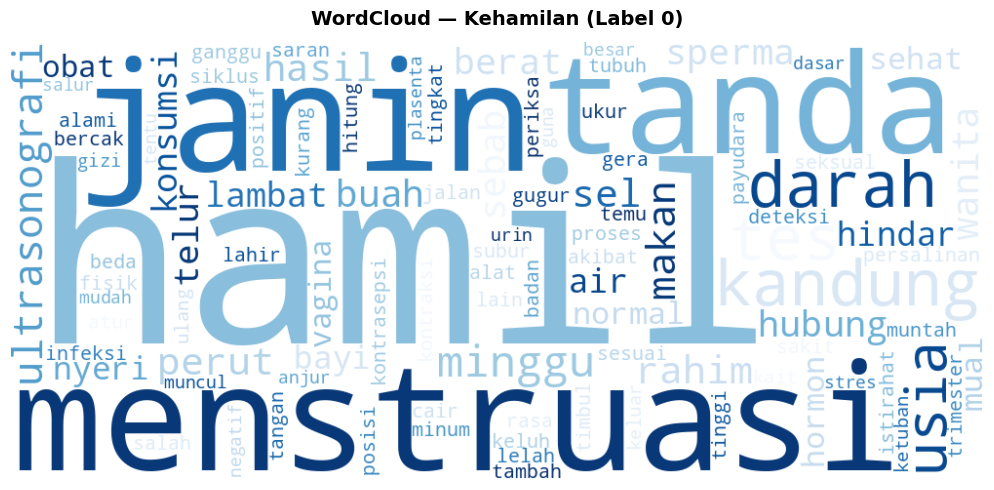

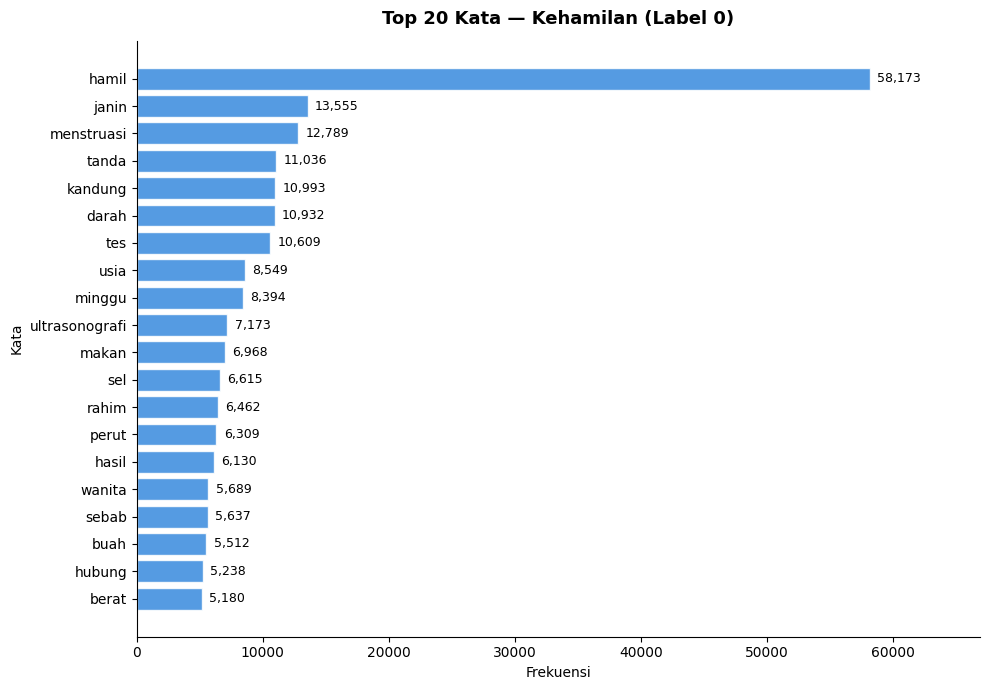

MENSTRUASI (Label 1)


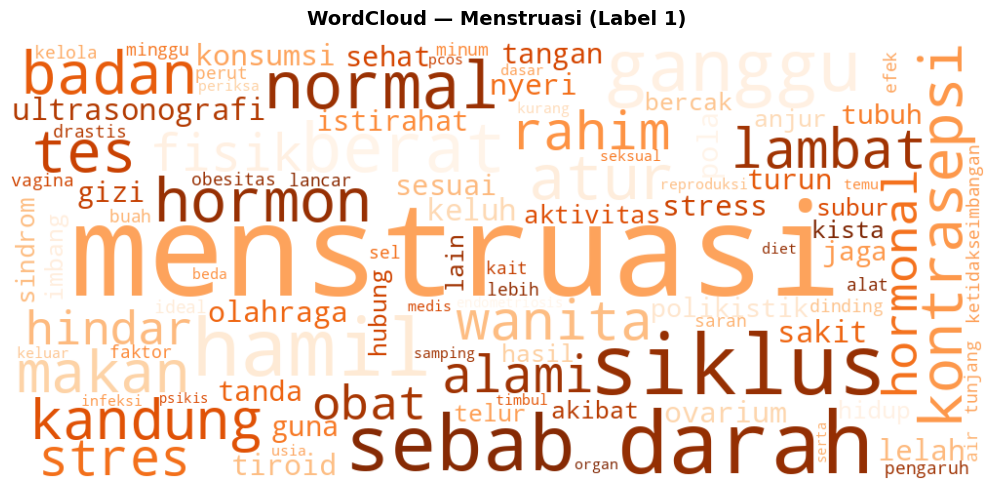

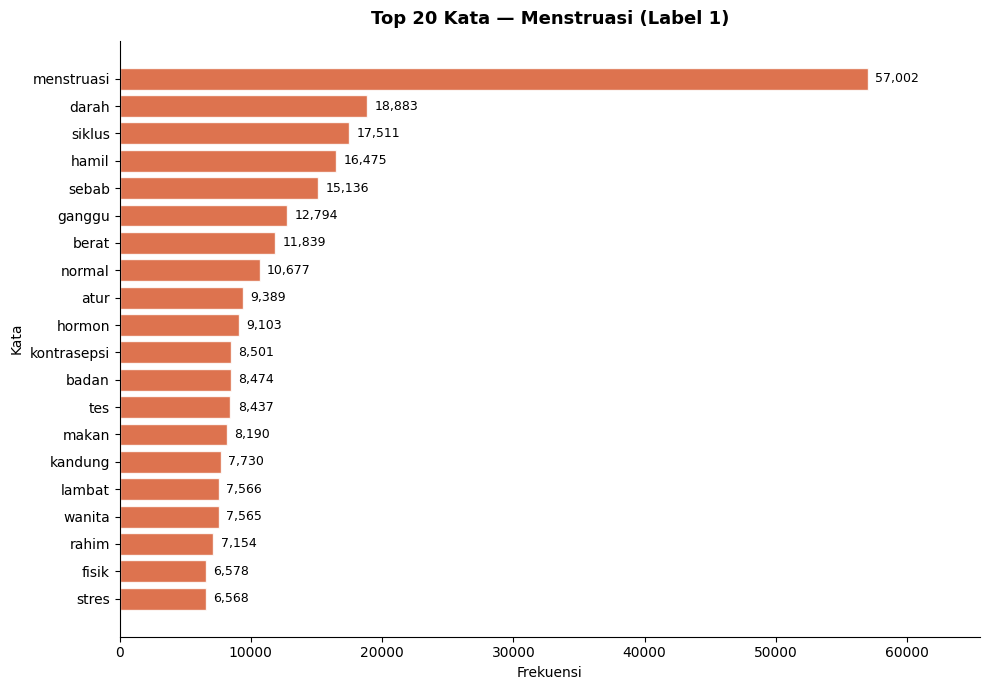

In [ ]:
%matplotlib inline

# LOAD DATA
df = pd.read_excel('data_stemming.xlsx')

if isinstance(df['tokens_stem'].iloc[0], str):
    df['tokens_stem'] = df['tokens_stem'].apply(ast.literal_eval)

# Pisahkan per label
df0 = df[df['label'] == 0]  # kehamilan
df1 = df[df['label'] == 1]  # menstruasi

# Hitung frekuensi
freq_all = Counter(k for tokens in df['tokens_stem'] for k in tokens)
freq0    = Counter(k for tokens in df0['tokens_stem'] for k in tokens)
freq1    = Counter(k for tokens in df1['tokens_stem'] for k in tokens)

print(f"Total data     : {len(df)} baris")
print(f"Kehamilan (0)  : {len(df0)} baris")
print(f"Menstruasi (1) : {len(df1)} baris\n")

# FUNGSI WORDCLOUD
def plot_wc(freq, title, colormap='viridis'):
    wc = WordCloud(
        width=1000, height=450,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False,
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(13, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

# FUNGSI TOP 20 KATA
def plot_top20(freq, title, color='#378ADD'):
    common = freq.most_common(20)
    words  = [w for w, _ in common]
    counts = [c for _, c in common]

    plt.figure(figsize=(10, 7))
    bars = plt.barh(words[::-1], counts[::-1],
                    color=color, alpha=0.85, edgecolor='white')

    for bar, count in zip(bars, counts[::-1]):
        plt.text(
            bar.get_width() + max(counts) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=9
        )

    plt.title(title, fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Frekuensi', fontsize=10)
    plt.ylabel('Kata', fontsize=10)
    plt.xlim(0, max(counts) * 1.15)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# 1. SEMUA DATA
print("=" * 40)
print("SEMUA DATA")
print("=" * 40)
plot_wc(freq_all,    'WordCloud — Semua Data',     colormap='viridis')
plot_top20(freq_all, 'Top 20 Kata — Semua Data',   color='#1D9E75')

# 2. KEHAMILAN (Label 0)
print("=" * 40)
print("KEHAMILAN (Label 0)")
print("=" * 40)
plot_wc(freq0,    'WordCloud — Kehamilan (Label 0)',   colormap='Blues')
plot_top20(freq0, 'Top 20 Kata — Kehamilan (Label 0)', color='#378ADD')

# 3. MENSTRUASI (Label 1)
print("=" * 40)
print("MENSTRUASI (Label 1)")
print("=" * 40)
plot_wc(freq1,    'WordCloud — Menstruasi (Label 1)',   colormap='Oranges')
plot_top20(freq1, 'Top 20 Kata — Menstruasi (Label 1)', color='#D85A30')